In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score

import matplotlib.pyplot as plt

In [ ]:
data_path = "/content/drive/MyDrive/EmotionDataset/punctuation_augmented_isear.xlsx"

df = pd.read_excel(data_path)
df.head()

,Unnamed: 0,content,labels,emotion,clean_content
0,0,on days when i feel close to my partner and ot...,5,joy,day feel close partner friend feel peace also ...
1,1,every time i imagine that someone i love or i ...,4,fear,every time imagine someone love could contact ...
2,2,when i had been obviously unjustly treated and...,0,anger,obviously unjustly treated possibility elucida...
3,3,when i think about the short time that we live...,2,sadness,think short time live relate period life think...
4,4,at a gathering i found myself involuntarily si...,1,disgust,gathering found involuntarily sitting next two...


In [ ]:
print("Total samples:", len(df))
print(df["labels"].value_counts().sort_index())

print(
    "Average tokens per sample:",
    df["clean_content"].str.split().apply(len).mean()
)

Total samples: 22545
labels
0    3237
1    3198
2    3246
3    3213
4    3228
5    3276
6    3147
Name: count, dtype: int64
Average tokens per sample: 10.475316034597471


In [ ]:
X = df["clean_content"]
y = df["labels"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

I used TF-IDF nad nb count then i decided to go with nb count cuz it gives better results with naive bayes model

In [ ]:
nb_count = Pipeline([
    ("vectorizer", CountVectorizer(
        max_features=12000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

nb_count.fit(X_train, y_train)
y_pred = nb_count.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.7187846529163895
Macro F1: 0.7181228273132095

Classification Report:

              precision    recall  f1-score   support

           0     0.6706    0.7017    0.6858       647
           1     0.7333    0.7219    0.7276       640
           2     0.7401    0.7504    0.7452       649
           3     0.6722    0.6314    0.6512       643
           4     0.7866    0.7817    0.7842       646
           5     0.7570    0.7802    0.7684       655
           6     0.6677    0.6614    0.6645       629

    accuracy                         0.7188      4509
   macro avg     0.7182    0.7184    0.7181      4509
weighted avg     0.7185    0.7188    0.7185      4509



In [ ]:
nb_char = Pipeline([
    ("vectorizer", CountVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2
    )),
    ("nb", MultinomialNB(alpha=1.0))
])

nb_char.fit(X_train, y_train)
y_pred = nb_char.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.7010423597249944
Macro F1: 0.7011873240848002

Classification Report:

              precision    recall  f1-score   support

           0     0.6693    0.6600    0.6646       647
           1     0.7797    0.7078    0.7420       640
           2     0.7007    0.7288    0.7145       649
           3     0.6442    0.6252    0.6346       643
           4     0.7911    0.7678    0.7793       646
           5     0.6978    0.7405    0.7185       655
           6     0.6353    0.6757    0.6549       629

    accuracy                         0.7010      4509
   macro avg     0.7026    0.7008    0.7012      4509
weighted avg     0.7028    0.7010    0.7014      4509



In [ ]:
best_nb = nb_count   # change if another performs better

y_train_pred = best_nb.predict(X_train)
y_test_pred  = best_nb.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred, average="macro")
test_f1  = f1_score(y_test, y_test_pred, average="macro")

print(f"Train F1: {train_f1:.4f}")
print(f"Test  F1: {test_f1:.4f}")
print(f"F1 Gap  : {train_f1 - test_f1:.4f}")

Train F1: 0.8376
Test  F1: 0.7181
F1 Gap  : 0.1195


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    best_nb,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

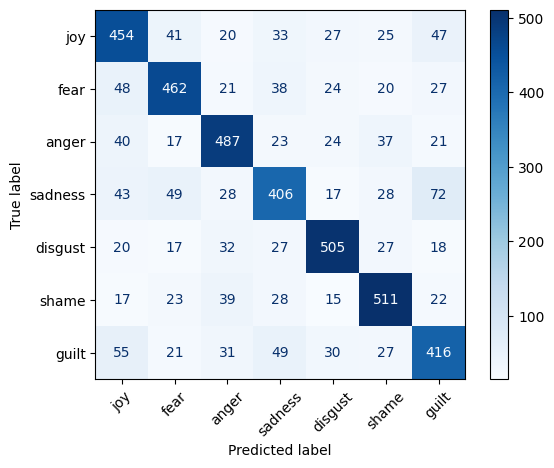

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_nb,
    X_test,
    y_test,
    display_labels=df["emotion"].unique(),
    cmap="Blues",
    xticks_rotation=45
)
plt.show()